In [180]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
from scipy.optimize import curve_fit
lumapiFile = "C:\\Program Files\\Lumerical\\v261\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

In [181]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [182]:
intcApi = lumapi.INTERCONNECT()

def FSR(lambda_, ng, dL):
    return lambda_**2/(ng*dL)

In [183]:
#units

## Length
nm = 1e-9
um = 1e-6
## Power
mW = 1e-3
## Time
ns = 1e-9
## Frequency
GHz = 1e9
THz = 1e12
## Resistance
kOhms = 1e3

# constants
lambda0 = 1550*nm
f0 = c/lambda0
lambda_range = 100*nm

lambda_min = lambda0 - lambda_range/2
lambda_max = lambda0 + lambda_range/2

f_min = c/lambda_max
f_max = c/lambda_min

frequency_range = f_max - f_min

L_wvg = 100*um

# waveguide parameters

index_matrix = np.loadtxt('index.txt')
n_eff = index_matrix[0,0]
ng = index_matrix[0,1]

dT_max = 100 # K

dneff_max = np.max(index_matrix[:,0]) - np.min(index_matrix[:,0])
dL = lambda0/dneff_max

# Constructing the MZIs #

## MZI with two Y-branchs ##

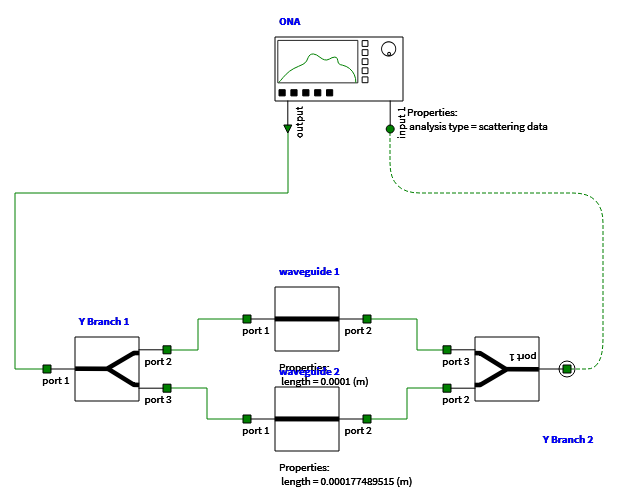

In [184]:
intcApi.deleteall()

intcApi.addelement('Waveguide Y Branch')
intcApi.set('name', 'Y Branch 1')
intcApi.set('x position', -200)
intcApi.set('y position', 0)

intcApi.addelement('Waveguide Y Branch')
intcApi.set('name', 'Y Branch 2')
intcApi.set('x position', 200)
intcApi.set('y position', 0)
for i in range(0,2,1):
    intcApi.rotateelement('Y Branch 2')

intcApi.addelement('Straight Waveguide')
intcApi.set('name', 'waveguide 1')
intcApi.set('x position', 0)
intcApi.set('y position', -50)
intcApi.set('effective index 1', n_eff)
intcApi.set('group index 1', ng)
intcApi.set('frequency', f0)
intcApi.set('length', L_wvg)

intcApi.addelement('Straight Waveguide')
intcApi.set('name', 'waveguide 2')
intcApi.set('x position', 0)
intcApi.set('y position', 50)
intcApi.set('effective index 1', n_eff)
intcApi.set('group index 1', ng)
intcApi.set('frequency', f0)
intcApi.set('length', L_wvg + dL)
#intcApi.set('use global temperature', 0)

intcApi.addelement('Optical Network Analyzer')
intcApi.set('name', 'ONA')
intcApi.set('x position', 0)
intcApi.set('y position', -300)
intcApi.set('center frequency', f0)
intcApi.set('frequency range', frequency_range)

intcApi.connect('ONA', 'output', 'Y Branch 1', 'port 1')
intcApi.connect('Y Branch 1', 'port 2', 'waveguide 1', 'port 1')
intcApi.connect('Y Branch 1', 'port 3', 'waveguide 2', 'port 1')
intcApi.connect('waveguide 1', 'port 2', 'Y Branch 2', 'port 3')
intcApi.connect('waveguide 2', 'port 2', 'Y Branch 2', 'port 2')
intcApi.connect('Y Branch 2', 'port 1', 'ONA', 'input 1')

intcApi.save('MZI_interconnect')
intcApi.exportimage('MZI with Y branchs.png')

image_file_png = "C:/Users/LucasGabriel/OneDrive/Documentos/Layouts_and_simulations/Lumerical/Laboratories/MZI/MZI with Y Branchs.png"
#image_file_svg = "C:/Users/LucasGabriel/OneDrive/Documentos/Layouts_and_simulations/Lumerical/Laboratories/90_optical_hybrid/circuito_teste.svg"
from IPython.display import Image, display

display(Image(filename=image_file_png))

### running the simulations ###

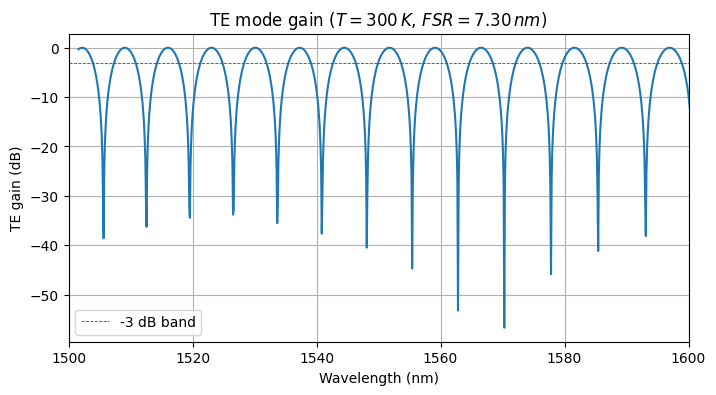

In [185]:
# Base simulation
intcApi.run()

results = intcApi.getresult('ONA', 'input 1/mode 1/gain')
Gain = results['TE gain (dB)']
lambda_array = results['wavelength']

plt.plot(lambda_array/nm, Gain)
plt.grid(True)
plt.xlabel('Wavelength (nm)')
plt.ylabel('TE gain (dB)')
plt.xlim([1500, 1600])
plt.title(r'TE mode gain ($T=300\,K$, $FSR = %.2f\,nm$)' %(FSR(lambda0, ng, dL)/nm))
plt.axhline(-3, ls = '--', color = 'red', label = '-3 dB band', linewidth = 0.6)
plt.legend(loc = 'best')
plt.show()

intcApi.switchtodesign()

In [186]:
# Simulations with different temperatures

TE_gain_dB_array = []

for k in range(0, len(index_matrix[:,0]), 1):
    intcApi.switchtodesign()
    for i in range(1, 3, 1):
        intcApi.setnamed('waveguide %d' %i, 'effective index 1', index_matrix[k,0])
        intcApi.setnamed('waveguide %d' %i, 'group index 1', index_matrix[k,1])
    intcApi.run()
    results = intcApi.getresult('ONA', 'input 1/mode 1/gain')
    TE_gain_dB_array.append(results['TE gain (dB)'])

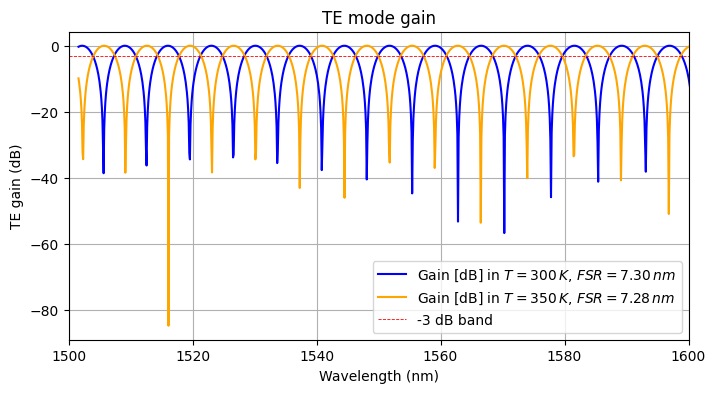

In [191]:
k = 5

T = 300 #K
T_array = np.linspace(T, T + dT_max, len(TE_gain_dB_array))

plt.plot(lambda_array/nm, Gain, label = r'Gain [dB] in $T = %d\,K$, $FSR = %.2f\,nm$' %(T, FSR(lambda0, ng, dL)/nm), color = 'blue')
plt.plot(lambda_array/nm, TE_gain_dB_array[k], label = r'Gain [dB] in $T = %d\,K$, $FSR = %.2f\,nm$' %(T_array[k], FSR(lambda0, index_matrix[k,1], dL)/nm), color = 'orange')
plt.grid(True)
plt.xlabel('Wavelength (nm)')
plt.ylabel('TE gain (dB)')
plt.xlim([1500, 1600])
plt.title(r'TE mode gain')
plt.axhline(-3, ls = '--', color = 'red', label = '-3 dB band', linewidth = 0.6)
plt.legend(loc = 'best')
plt.show()

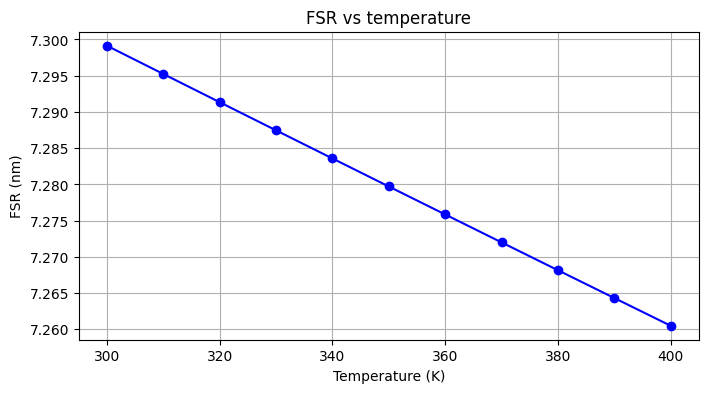

In [188]:
FSR_array = np.zeros(len(TE_gain_dB_array))

for k in range(0, len(TE_gain_dB_array), 1):
    FSR_array[k] = FSR(lambda0, index_matrix[k,1], dL)
    
plt.plot(T_array, FSR_array/nm, 'o-', color = 'blue')
plt.grid(True)
plt.xlabel('Temperature (K)')
plt.ylabel('FSR (nm)')
plt.title(r'FSR vs temperature')
plt.show()

In [189]:
intcApi.close()